# Data Cleaning

In [1]:
import pandas as pd

In [3]:
pd.read_excel("lazada-products.xlsx")
df = pd.read_excel("lazada-products.xlsx")
df.head()

,url,title,rating,reviews,initial_price,final_price,currency,image,seller_name,breadcrumb,...,color,returns_and_warranty,is_super_seller,promotions,brand,product_variation,lazmall,domain,number_sold,gmv
0,https://www.lazada.co.id/products/dioda-damper...,DIODA DAMPER DMV 1500 TV POLYTRON NEW ORIGINAL...,4.6,27,0.0,10000.0,IDR,"[""https://img.lazcdn.com/g/ff/kf/Sc92f4b3c99c0...",YUDIANA YUDI SPERPAT ELEKTRONIK,"[""Televisi & Video"",""Televisi Digital""]",...,NaN,"[""Berubah Pikiran"",""7 Hari Gratis Pengembalian...",False,[],TR,[],False,https://www.lazada.co.id,111,1110000.0
1,https://www.lazada.co.id/products/victus-lapto...,Victus Laptop Gaming HP AMD Ryzen 5 NVIDIA GeF...,0.0,0,17555000.0,16499000.0,IDR,"[""https://img.lazcdn.com/g/p/3440632c069eddd82...",HP,"[""Komputer & Laptop"",""Laptop"",""Laptop Umum""]",...,NaN,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Varian"",""value"":""15-fb2666AX""}]",True,https://www.lazada.co.id,0,0.0
2,https://www.lazada.co.id/products/laptop-hp-15...,Laptop HP 15s-fq5148TU Core i3 UHD 4GB & 8GB R...,5.0,47,6499000.0,6099000.0,IDR,"[""https://img.lazcdn.com/g/p/23782d5f1bd37a89c...",HP,"[""Komputer & Laptop"",""Laptop"",""Laptop Umum""]",...,14s-dq5115TU,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Warna"",""value"":""14s-dq5115TU""}]",True,https://www.lazada.co.id,91,555009000.0
3,https://www.lazada.co.id/products/printer-hp-d...,Printer HP DeskJet 2336 All in One ( Print Sca...,5.0,177,990000.0,880000.0,IDR,"[""https://img.lazcdn.com/g/p/bf68d11f46c85761a...",HP,"[""Pencetak & Monitor"",""Printer"",""Printer Ink J...",...,2336 Putih,"[""Produk Original"",""Berubah Pikiran"",""30 Hari ...",True,[],HP,"[{""name"":""Warna"",""value"":""2336 Putih""}]",True,https://www.lazada.co.id,409,359920000.0
4,https://www.lazada.co.id/products/roda-koper-r...,"RODA KOPER, RODA PENGGANTI, RODA DOUBLE WHEEL,...",5.0,2,0.0,65000.0,IDR,"[""https://img.lazcdn.com/g/p/abc4f89073ba5380c...",dewi05588,"[""Tas & Travel"",""Tas Anak"",""Koper""]",...,NaN,"[""Berubah Pikiran"",""7 Hari Gratis Pengembalian...",False,[],Tidak Ada Merk,"[{""name"":""RODA"",""value"":""AUDI""}]",False,https://www.lazada.co.id,2,130000.0


In [4]:
# Check missing values
print(df.isnull().sum())

url                         0
title                       0
rating                      0
reviews                     0
initial_price               0
final_price                 0
currency                    0
image                       0
seller_name                 0
breadcrumb                  0
product_specifications      0
product_description         0
seller_ratings             27
seller_ship_on_time        67
seller_chat_response      122
sku                         0
mpn                         0
colors                    500
variations                  0
color                     500
returns_and_warranty        0
is_super_seller             0
promotions                  0
brand                       0
product_variation           0
lazmall                     0
domain                      0
number_sold                 0
gmv                         0
dtype: int64


In [5]:
# Remove duplicates
df = df.drop_duplicates()

In [6]:
# Fill missing categorical values
categorical_cols = ['brand','color','seller_name']
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

In [7]:
# Fill missing numerical values
numerical_cols = ['rating','reviews','initial_price',
                  'final_price','number_sold','gmv']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


In [8]:
# Check data information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     1000 non-null   object 
 1   title                   1000 non-null   object 
 2   rating                  1000 non-null   float64
 3   reviews                 1000 non-null   int64  
 4   initial_price           1000 non-null   float64
 5   final_price             1000 non-null   float64
 6   currency                1000 non-null   object 
 7   image                   1000 non-null   object 
 8   seller_name             1000 non-null   object 
 9   breadcrumb              1000 non-null   object 
 10  product_specifications  1000 non-null   object 
 11  product_description     1000 non-null   object 
 12  seller_ratings          973 non-null    float64
 13  seller_ship_on_time     933 non-null    float64
 14  seller_chat_response    878 non-null    f

# Exploratory Data Analysis

In [9]:
print(df.describe())

            rating       reviews  initial_price   final_price  seller_ratings  \
count  1000.000000   1000.000000   1.000000e+03  1.000000e+03      973.000000   
mean      3.440500    305.804000   8.633704e+05  8.489552e+05        0.964923   
std       2.241614    959.768669   4.349092e+06  4.047588e+06        0.033989   
min       0.000000      0.000000   0.000000e+00  1.000000e-02        0.810000   
25%       0.000000      0.000000   0.000000e+00  1.340500e+01        0.950000   
50%       4.900000     14.000000   3.990000e+01  7.390000e+02        0.970000   
75%       5.000000     86.500000   9.999000e+03  1.620000e+04        0.990000   
max       5.000000  13703.000000   3.399900e+07  3.124900e+07        1.000000   

       seller_ship_on_time  seller_chat_response           mpn    number_sold  \
count           933.000000            878.000000  1.000000e+03    1000.000000   
mean              0.935981              0.982232  4.699949e+09    1379.904000   
std               0.129412 

# Visualizations to Create in Python

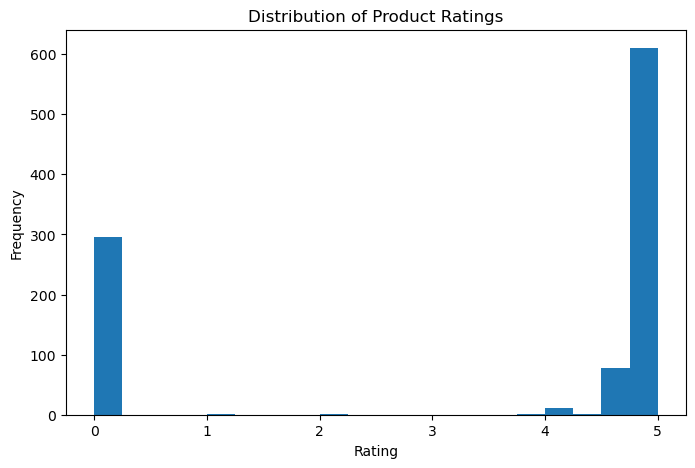

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['rating'], bins=20)

plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Distribution of Product Ratings")
plt.show()

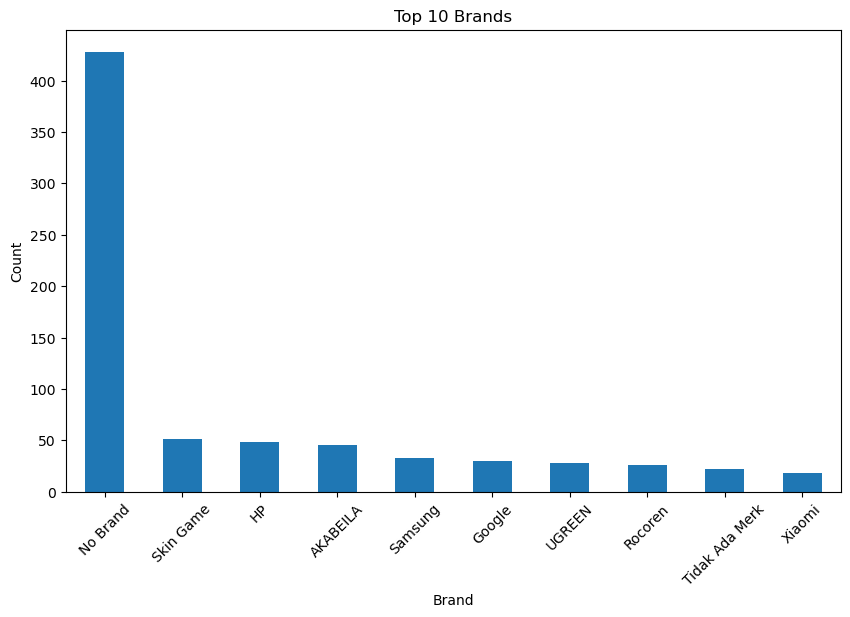

In [11]:
top_brands = df['brand'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_brands.plot(kind='bar')

plt.xlabel("Brand")
plt.ylabel("Count")
plt.title("Top 10 Brands")
plt.xticks(rotation=45)

plt.show()

# Relationship between sales and GMV

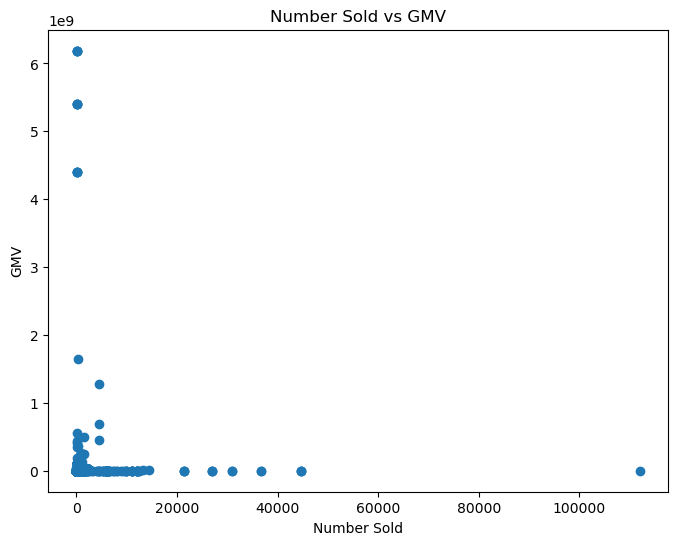

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['number_sold'],
    df['gmv']
)

plt.xlabel("Number Sold")
plt.ylabel("GMV")
plt.title("Number Sold vs GMV")

plt.show()

# Interpretation for your report

The Lazada dataset was cleaned by handling missing values and removing duplicate records. 
Exploratory analysis revealed that product sales are highly uneven, with a small number of 
products contributing disproportionately to total revenue. "No Brand" products constituted the 
largest share of listings, followed by Skin Game, HP, and Samsung. Product sales exhibited strong 
variability, ranging from zero to over 112,000 units sold. The GMV values also showed significant dispersion, 
indicating the presence of high-performing products that dominate marketplace revenue. These findings suggest 
a long-tail distribution commonly observed in e-commerce platforms.